# Paso 4: Mapeo de Clases a Categorías

Este notebook implementa el **Paso 4** del pipeline para la tesis:
**"Detección de ataques minoritarios en redes IoT mediante un modelo híbrido basado en Stacking, XGBoost y LightGBM, Puno 2026"**.

### Objetivos del Notebook:
1. **Mapear** las 34 etiquetas originales del dataset `CICIoT2023` en **8 categorías principales** (DDoS, DoS, Mirai, Recon, Spoofing, Brute Force, Web-based, y Benign).
2. Analizar la nueva distribución de la variable objetivo y evaluar el desbalance a nivel de categorías.
3. Generar un gráfico de distribución premium de las categorías para la tesis.
4. Guardar el dataset resultante en `data/processed/dataset_mapeado.csv`.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cambiar el directorio de trabajo a la raíz del proyecto si el notebook se ejecuta desde 'notebooks'
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f"Directorio de trabajo activo: {os.getcwd()}")

# Configuración visual para la tesis
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (12, 6)

Directorio de trabajo activo: /home/carmen/tesis_iot


In [2]:
# Cargar el dataset limpio y escalado generado en el Paso 3
df_path = "data/processed/dataset_limpio.csv"
print("Cargando dataset limpio...")
df = pd.read_csv(df_path)
print(f"¡Cargado con éxito! Filas: {len(df):,}, Columnas: {df.shape[1]}")

Cargando dataset limpio...
¡Cargado con éxito! Filas: 2,515,882, Columnas: 37


## 1. Definición del Diccionario de Mapeo

Mapeamos las 34 etiquetas originales del dataset a las 8 clases estándar de la literatura científica para `CICIoT2023` (7 categorías de ataque + 1 benigna).

In [3]:
clases_a_categorias = {
    # DDoS Category
    'DDOS-ACK_FRAGMENTATION': 'DDoS',
    'DDOS-HTTP_FLOOD': 'DDoS',
    'DDOS-ICMP_FLOOD': 'DDoS',
    'DDOS-ICMP_FRAGMENTATION': 'DDoS',
    'DDOS-PSHACK_FLOOD': 'DDoS',
    'DDOS-RSTFINFLOOD': 'DDoS',
    'DDOS-SLOWLORIS': 'DDoS',
    'DDOS-SYN_FLOOD': 'DDoS',
    'DDOS-SYNONYMOUSIP_FLOOD': 'DDoS',
    'DDOS-TCP_FLOOD': 'DDoS',
    'DDOS-UDP_FLOOD': 'DDoS',
    'DDOS-UDP_FRAGMENTATION': 'DDoS',
    
    # DoS Category
    'DOS-HTTP_FLOOD': 'DoS',
    'DOS-SYN_FLOOD': 'DoS',
    'DOS-TCP_FLOOD': 'DoS',
    'DOS-UDP_FLOOD': 'DoS',
    
    # Mirai Category
    'MIRAI-GREETH_FLOOD': 'Mirai',
    'MIRAI-GREIP_FLOOD': 'Mirai',
    'MIRAI-UDPPLAIN': 'Mirai',
    
    # Recon Category
    'RECON-HOSTDISCOVERY': 'Recon',
    'RECON-OSSCAN': 'Recon',
    'RECON-PINGSWEEP': 'Recon',
    'RECON-PORTSCAN': 'Recon',
    'VULNERABILITYSCAN': 'Recon',
    
    # Spoofing Category
    'MITM-ARPSPOOFING': 'Spoofing',
    'DNS_SPOOFING': 'Spoofing',
    
    # Brute Force Category
    'DICTIONARYBRUTEFORCE': 'Brute Force',
    
    # Web-based Category
    'BROWSERHIJACKING': 'Web-based',
    'COMMANDINJECTION': 'Web-based',
    'SQLINJECTION': 'Web-based',
    'XSS': 'Web-based',
    'BACKDOOR_MALWARE': 'Web-based',
    'UPLOADING_ATTACK': 'Web-based',
    
    # Benign Category
    'BENIGN': 'Benign'
}

# Verificar que todas las etiquetas actuales estén cubiertas en el diccionario
labels_actuales = set(df['Label'].unique())
labels_mapeadas = set(clases_a_categorias.keys())
no_cubiertas = labels_actuales - labels_mapeadas

if len(no_cubiertas) == 0:
    print("¡Excelente! Todas las etiquetas del dataset están mapeadas correctamente.")
else:
    print(f"Advertencia: Etiquetas no mapeadas: {no_cubiertas}")

¡Excelente! Todas las etiquetas del dataset están mapeadas correctamente.


## 2. Aplicar el Mapeo

In [4]:
# Reemplazar la columna Label por la nueva categoría
df['Label'] = df['Label'].map(clases_a_categorias)

# Comprobar que no haya valores nulos introducidos tras el mapeo
nulos_label = df['Label'].isna().sum()
print(f"Nulos en la columna Label después de mapear: {nulos_label}")

Nulos en la columna Label después de mapear: 0


## 3. Analizar la Nueva Distribución de Clases (8 Categorías)

In [5]:
class_counts = df['Label'].value_counts()
dist_final = pd.DataFrame({
    'Cantidad': class_counts,
    'Porcentaje': (class_counts / len(df) * 100).round(4)
})
print("Nueva distribución de las 8 categorías:")
print(dist_final)

# Guardar en los resultados
dist_final.to_csv("results/distribucion_categorias.csv")

Nueva distribución de las 8 categorías:
             Cantidad  Porcentaje
Label                            
DDoS           989833     39.3434
Recon          414981     16.4945
Mirai          369568     14.6894
DoS            346300     13.7646
Spoofing       233698      9.2889
Benign         125275      4.9794
Web-based       23707      0.9423
Brute Force     12520      0.4976


## 4. Generar Gráfico de Distribución para la Tesis

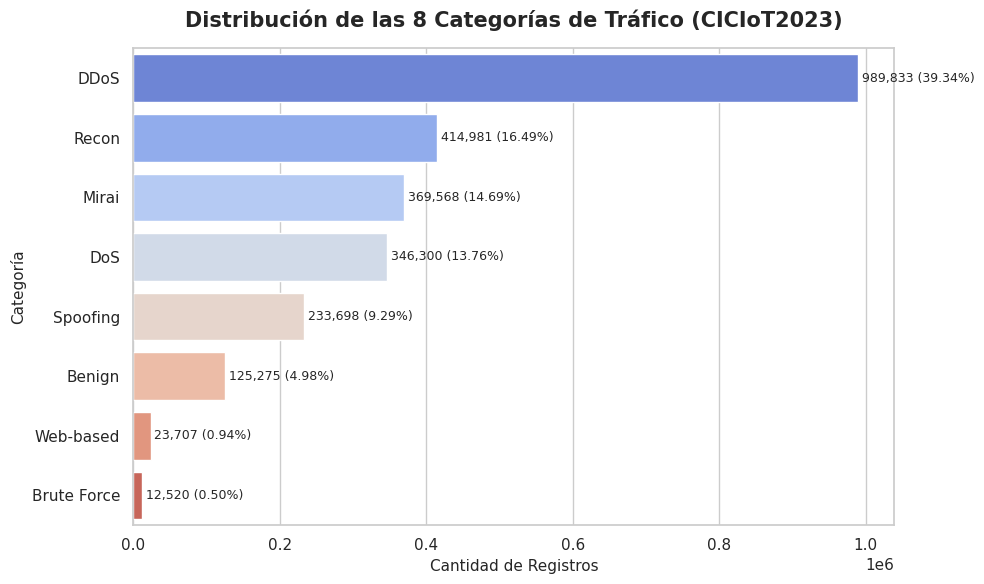

In [6]:
# Gráfico de barras horizontal premium para las categorías
plt.figure(figsize=(10, 6))
colors = sns.color_palette("coolwarm", len(class_counts))
sns.barplot(y=class_counts.index, x=class_counts.values, palette=colors, hue=class_counts.index, legend=False)

plt.title("Distribución de las 8 Categorías de Tráfico (CICIoT2023)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Cantidad de Registros", fontsize=11)
plt.ylabel("Categoría", fontsize=11)

# Colocar las etiquetas de conteo al final de cada barra
for index, value in enumerate(class_counts.values):
    plt.text(value + (max(class_counts.values)*0.005), index, f"{value:,} ({value/len(df)*100:.2f}%)", va='center', fontsize=9)

plt.tight_layout()
plt.savefig("results/figures/06_distribucion_categorias.png", dpi=300)
plt.show()

## 5. Guardar Dataset Mapeado

In [7]:
output_path = "data/processed/dataset_mapeado.csv"
print(f"Guardando dataset mapeado en {output_path}...")
df.to_csv(output_path, index=False)
print("¡Dataset guardado correctamente!")

Guardando dataset mapeado en data/processed/dataset_mapeado.csv...
¡Dataset guardado correctamente!
